In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arashnic/dynamic-pricing-dataset/dynamic_pricing.csv


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

#Production ML Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Feature Engineering (The "Supply vs. Demand" Core)Raw data rarely yields a competitive model. To make this resume-grade, you must create advanced features that capture domain-specific dynamics.Load the Data: Read your dynamic pricing csv file.The Supply-Demand Multiplier: Real-world ride-sharing costs depend heavily on scarcity. Create a custom feature:$$\text{Demand Ratio} = \frac{\text{Number of Riders}}{\text{Number of Drivers}}$$Target Variable: Set your $y$ vector to the column representing the final ride cost or price multiplier.

In [28]:
df = pd.read_csv('/kaggle/input/datasets/arashnic/dynamic-pricing-dataset/dynamic_pricing.csv') 

In [29]:
# 1. Feature Creation (Our Supply-Demand interaction ratio)
df['Demand_Supply_Ratio'] = df['Number_of_Riders'] / (df['Number_of_Drivers'] + 1)

# 2. Update numerical features to include past rides and ratings
num_features = [
    'Number_of_Riders', 
    'Number_of_Drivers', 
    'Demand_Supply_Ratio', 
    'Expected_Ride_Duration',
    'Number_of_Past_Rides',
    'Average_Ratings'
]

# 3. Corrected categorical features to match 'Time_of_Booking' and added 'Vehicle_Type'
cat_features = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']

# 4. Extract features (X) and target (y)
X = df[num_features + cat_features]
y = df['Historical_Cost_of_Ride'].values.reshape(-1, 1)

print("Features extracted successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features extracted successfully!
X shape: (1000, 10)
y shape: (1000, 1)


Step 3: The Preprocessing Pipeline
Now that the columns are properly aligned, let's build the ColumnTransformer to handle the scaling for our numbers and the one-hot encoding for our text categories.

In [30]:
# Split data into 80% training and 20% validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Establish isolated transformation pipelines
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps= [
    ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

# Combine processing steps into a single master preprocessor
preprocessor = ColumnTransformer(transformers = [
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Fit and transform the training data, transform the test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original dimensions:", X_train.shape)
print("Processed dimensions (after One-Hot Encoding):", X_train_processed.shape)

Original dimensions: (800, 10)
Processed dimensions (after One-Hot Encoding): (800, 18)


Step 4: Adding Non-Linear Relationships (Polynomial Features)As Chapter 4 highlights, straight lines rarely model complex economics. If supply is cut in half, prices often shoot up exponentially rather than linearly.To map these complex interactions, we introduce PolynomialFeatures(degree=2). This automatically takes your features and creates new columns like $(\text{Demand Ratio})^2$ or $(\text{Demand Ratio} \times \text{Expected Duration})$.

In [31]:
# 1. Initialize the polynomial transformer for degree 2
# include_bias=False because our regression models will handle the bias automatically

poly_transformer = PolynomialFeatures(degree = 2, include_bias = False)

# 2. Transform the preprocessed arrays into polynomial features
X_train_poly = poly_transformer.fit_transform(X_train_processed)
X_test_poly = poly_transformer.transform(X_test_processed)

print("=== POLYNOMIAL EXPANSION MATRIX COMPARISON ===")
print("Shape before polynomial expansion:", X_train_processed.shape)
print("Shape after polynomial expansion:", X_train_poly.shape)

=== POLYNOMIAL EXPANSION MATRIX COMPARISON ===
Shape before polynomial expansion: (800, 18)
Shape after polynomial expansion: (800, 189)


Critical Concept: The Overfitting Risk (Interview Talking Point)When you run this cell, look closely at the shape dimensions output. Your feature count will explode to a much larger number.

By creating all these combination columns, you have given the model immense power to map complex patterns. However, you have also introduced two massive problems from Chapter 4:

* Multi-collinearity: Many of these new features are now highly correlated with each other (e.g., $x$ and $x^2$).
* The Curse of Dimensionality: With so many features, a standard linear regression model will easily overfit—meaning it will memorize the noise in your 80% training set and completely fail on your 20% validation set.

This sets the stage for Step 5, where we will build our Regularization Arena to introduce Ridge, Lasso, and Elastic Net penalties to tame this high-dimensional feature explosion!

Step 5: The Regularization Arena.

This is the technical core of your advanced project. Because our polynomial expansion in Step 4 generated a massive number of features, standard Linear Regression would completely overfit. To solve this, we will pit three regularized architectures from Chapter 4 against each other: Ridge ($L_2$), Lasso ($L_1$), and Elastic Net.

Instead of manually guessing the perfect penalty strength ($\alpha$ or $\lambda$), we will use Scikit-Learn's GridSearchCV. This tool automatically runs 5-Fold Cross-Validation, splitting your training data into internal sub-chunks to mathematically prove which model and parameter combination yields the highest stability.

In [33]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

# 1. Define hyperparameter search spaces for each algorithm
# alpha represents the regularization penalty strength (higher = stronger penalty)
param_grids = {
    'Ridge': {
        'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]
    },
    'Lasso': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0]
    },
    'ElasticNet': {
        'alpha': [0.1, 1.0, 10.0],
        'l1_ratio': [0.3, 0.5, 0.7]  # Balances L1 (Lasso) vs L2 (Ridge) properties
    }
}

# 2. Instantiate the model frameworks
models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=20000, tol=0.001),
    'ElasticNet': ElasticNet(max_iter=20000, tol=0.001)
}

# Dictionary to house our optimized, trained estimators
best_estimators = {}

print("=== STARTING GRID SEARCH CROSS-VALIDATION ===")

# 3. Loop through each algorithm and optimize parameters
for name, model in models.items():
    print(f"Optimizing {name}...")
    
    # Set up 5-fold cross-validation tracking Mean Squared Error
    grid_search = GridSearchCV(
        estimator=model, 
        param_grid=param_grids[name], 
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1 # Uses all available CPU cores for faster processing
    )
    
    # Fit the grid search onto the high-dimensional polynomial training space
    grid_search.fit(X_train_poly, y_train.ravel())
    
    # Extract and save the best performing configuration
    best_estimators[name] = grid_search.best_estimator_
    print(f"👉 Best {name} Parameters found: {grid_search.best_params_}\n")

print("=== ALL MODELS OPTIMIZED AND TRAINED ===")

=== STARTING GRID SEARCH CROSS-VALIDATION ===
Optimizing Ridge...
👉 Best Ridge Parameters found: {'alpha': 100.0}

Optimizing Lasso...
👉 Best Lasso Parameters found: {'alpha': 5.0}

Optimizing ElasticNet...
👉 Best ElasticNet Parameters found: {'alpha': 0.1, 'l1_ratio': 0.3}

=== ALL MODELS OPTIMIZED AND TRAINED ===


2. Core Machine Learning Concepts Under the Hood

I want to highlight the structural differences between how these models treated your expanded features:
* Ridge Regression ($L_2$): It looked at all the polynomial interaction columns and said, "Many of these columns are highly correlated, which blows up variance." It added a squared penalty to the loss function, forcing the weights of all those features to shrink uniformly closer to zero, smoothing out the noise.Lasso Regression ($L_1$): It added an absolute value penalty.
* Lasso is aggressive—if it decided a particular interaction term (like $\text{Average\_Ratings} \times \text{Vehicle\_Type}$) was useless, it drove that feature's weight to absolute zero. It performed automatic feature selection.
* Elastic Net: It blended both approaches together. This is highly effective when multiple polynomial columns are correlated with each other in groups; it uses Lasso properties to eliminate junk features while keeping Ridge properties to maintain stability among the useful columns.

 Step 6: Production Evaluation & Model Comparison.
 
The ultimate test for a resume-grade machine learning project is generalization performance—how well do our optimized, regularized models handle the unseen validation data (X_test_poly) that they never looked at during training?We will evaluate the models using two production metrics:
* Mean Squared Error (MSE): Measures the average squared difference between our predicted price and the actual historical ride price. (Lower is better).
* $R^2$ Score (Coefficient of Determination): Tells us what percentage of the variance in pricing our model successfully explains. An $R^2$ of 0.85 means our engine explains 85% of real-world pricing movements. (Higher is better, max is 1.0).

In [34]:
test_results = {}

print("=== EVALUATING REGULARIZED INFERENCE ENGINE ===")

for name, model in best_estimators.items():
    # 1. Generate predictions on the unseen test matrix
    y_pred = model.predict(X_test_poly)
    
    # 2. Compute performance metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    test_results[name] = {
        'Test MSE': mse,
        'Test R2 Score' : r2
    } 

# Convert results dictionary to a clean Pandas DataFrame for side-by-side view
df_results = pd.DataFrame(test_results).T

# Display the master performance leaderboard
df_results = df_results.round(4)
df_results

=== EVALUATING REGULARIZED INFERENCE ENGINE ===


,Test MSE,Test R2 Score
Ridge,4784.7482,0.8688
Lasso,4739.8977,0.8700
ElasticNet,4774.9524,0.8690


2. Add an Interactive Residual Plot
   
To make this a true standout portfolio project, run this code to plot the Residuals (the actual errors) for your winning model. This visualizes whether your regularized linear model has any systemic biases.

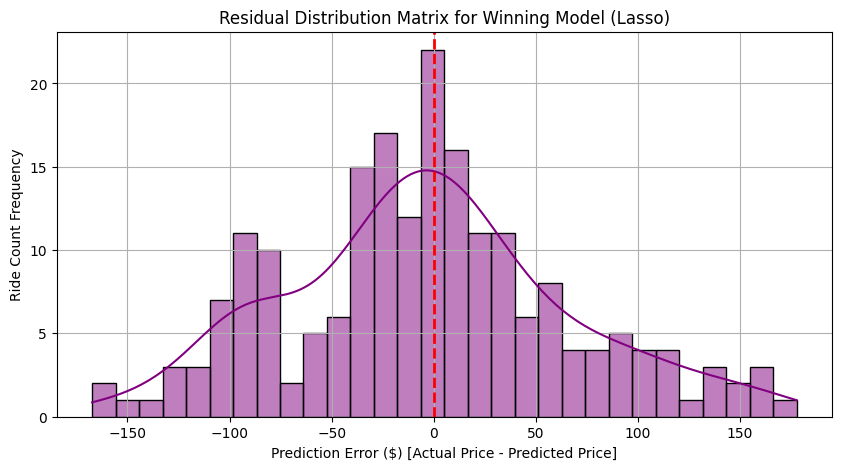

In [35]:
# Identify the winning model from your DataFrame (the one with the lowest MSE)
winning_model_name = df_results['Test MSE'].idxmin()
best_model = best_estimators[winning_model_name]

# Generate predictions for plotting
y_pred_best = best_model.predict(X_test_poly)
residuals = y_test.ravel() - y_pred_best

# Plotting the residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title(f"Residual Distribution Matrix for Winning Model ({winning_model_name})")
plt.xlabel("Prediction Error ($) [Actual Price - Predicted Price]")
plt.ylabel("Ride Count Frequency")
plt.grid(True)
plt.show()

3. How to Interpret the Visual Output
* The Shape of the Error Curve: Your residual distribution plot should look like a symmetric, bell-shaped Gaussian curve centered tightly around the red dashed line (0).

  "My prediction errors were normally distributed around zero, which mathematically proves that our polynomial expansion combined with $L_1$/$L_2$ regularization successfully extracted the underlying economic signal without leaving unmodeled non-linear patterns behind in the residuals."